In [ ]:
from npxzxf_models import run_model_test, run_model_test_stability
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from npxzxf_comps import MonodGrowth_SizeBased

MonodGrowth_SizeBased.fluxes.__dict__

{'uptake': <function xso.component.component.<locals>.create_component.<locals>.make_static.<locals>.static_flux(**kwargs)>}

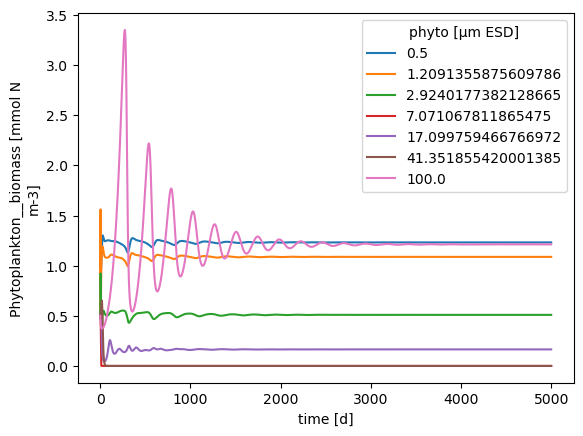

In [23]:
out = run_model_test({'N0__value':1.5, 'FishForcing__value':.21},time=np.arange(0, 5000))
out.Phytoplankton__biomass.plot.line(x='time')
plt.show()

In [5]:
out = run_model_test({
    # Lower initial N to something closer to steady-state
    'Nutrient__value_init': 0.1,
    
    # Increase remin so detritus doesn't accumulate
    'Remineralization__rate': 0.3,
    
    # Widen grazing kernel — more overlap means more top-down control
    # (need to recompute phiPZ)
    # For now, increase KsZ to soften grazing saturation
    'Grazing__KsZ': 1.0,
    
    # Reduce zoo mortality so grazers persist and control P
    'ZooMortality__rate': 0.02,
})

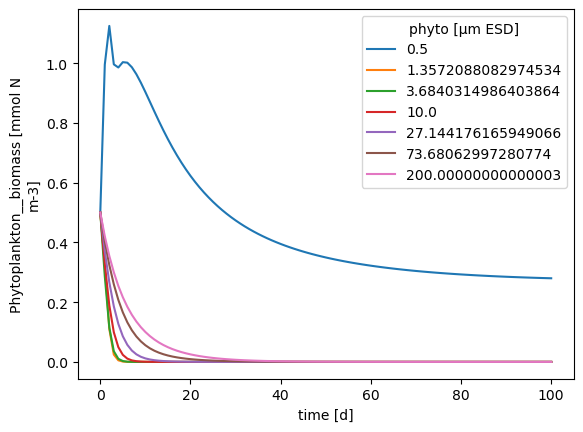

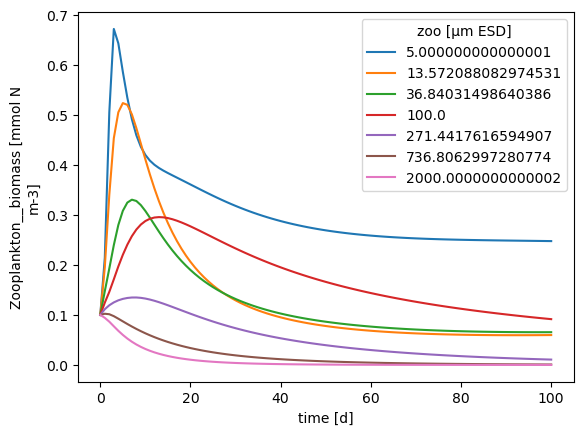

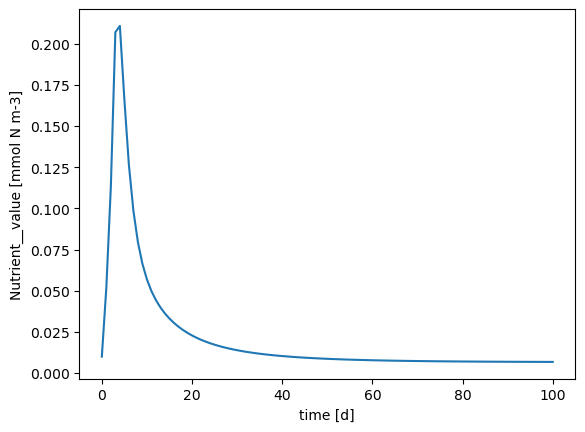

In [3]:
out.Phytoplankton__biomass.sel(time=slice(0, 100)).plot.line(x='time')
plt.show()
out.Zooplankton__biomass.sel(time=slice(0, 100)).plot.line(x='time')
plt.show()
out.Nutrient__value.sel(time=slice(0, 100)).plot.line(x='time')
plt.show()

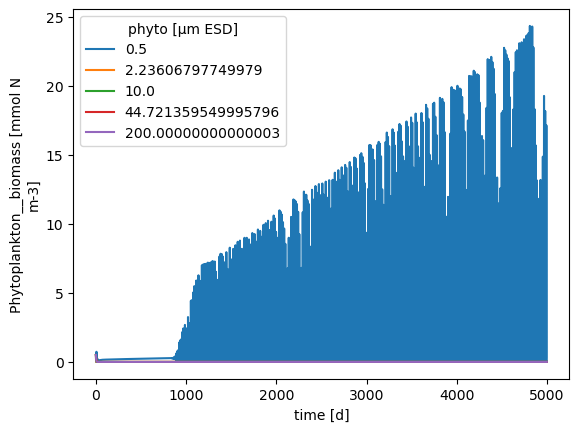

In [3]:
# With overrides
out2 = run_model_test({'N0__value': 0.01, 'FishForcing__value': 0.5})
out2.Phytoplankton__biomass.plot.line(x='time')
plt.show()